# IKEA Product Catalog Analysis

This notebook keeps the same analyses and plots as the original version, but the code has been cleaned up and shortened by moving repeated operations into reusable helper functions.

**Dataset logic:** each row represents an IKEA product in one country, so the same `product_id` can appear multiple times across European markets. The notebook focuses on prices, online availability, category distribution, ratings, reviews, promotional tags, and country-level differences.


## Setup

In [1]:
import re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import Patch
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid')


## Reusable constants and helper functions

In [2]:
EUROPEAN_COUNTRIES = ['Austria','Belgium','Bulgaria','Croatia','Czech Republic','Denmark','Estonia','Finland','France','Germany','Greece','Hungary','Ireland','Italy','Latvia','Lithuania','Netherlands','Norway','Poland','Portugal','Romania','Serbia','Slovakia','Slovenia','Spain','Sweden','Switzerland','United Kingdom']

EUR_RATES = {'EUR':1, 'GBP':1.17, 'CHF':1.05, 'SEK':0.087, 'NOK':0.086, 'DKK':0.134, 'PLN':0.23, 'CZK':0.040, 'HUF':0.0026, 'RON':0.20, 'RSD':0.0085}

PRICE_BINS, PRICE_LABELS = [0,10,25,50,100,250,float('inf')], ['< €10','€10–25','€25–50','€50–100','€100–250','€250+']

CATEGORY_COLORS = {'Baby & children':'#4E79A7','Bathroom and Laundry':'#F28E2B','Beds & mattresses':'#E15759','Decoration':'#76B7B2','Food & beverages':'#59A14F','Kitchen':'#EDC948','Kitchens':'#EDC948','Kitchenware':'#B07AA1','Lighting and electronics':'#FF9DA7','Outdoor':'#9C755F','Pet products':'#BAB0AC','Sofas & armchairs':'#86BCB6','Storage & organization':'#D37295','Tables & chairs':'#FABFD2','Textiles':'#8CD17D','Other':'#999999'}

def to_num(df, cols):
    df = df.copy(); df[cols] = df[cols].apply(pd.to_numeric, errors='coerce'); return df

def as_bool(s):
    return s.astype(str).str.strip().str.lower().map({'true':True,'false':False,'1':True,'0':False,'yes':True,'no':False})

def add_price_eur(df):
    df = to_num(df, ['price']); 
    return df.assign(price_eur=df['price'] * df['currency'].map(EUR_RATES))

def rated_products(df, min_reviews=10, extra_cols=None):
    cols = ['product_rating','product_rating_count']; keep = cols + (extra_cols or [])
    return to_num(df, cols).dropna(subset=keep).query('product_rating_count >= @min_reviews').copy()

def top_values(df, col, n=10):
    return df[col].value_counts().head(n).index

def add_bar_labels(ax, values, fmt='{:.0f}', offset=None, fontsize=10):
    values = list(values); offset = (max(values) * .01 if offset is None and values else 0)
    for i, v in enumerate(values): ax.text(i, v + offset, fmt.format(v), ha='center', va='bottom', fontsize=fontsize)

def style_axes(axes, labelsize=11):
    for ax in np.ravel(axes): ax.tick_params(axis='both', labelsize=labelsize)

def country_price_band(v):
    return 'Below median' if v < 95 else 'Aligned' if v <= 105 else 'Above median'

def box_stats(df, group_col, value_col, groups):
    rows = []
    for g in groups:
        v = df.loc[df[group_col].eq(g), value_col].dropna(); q1, med, q3 = v.quantile(.25), v.median(), v.quantile(.75); iqr = q3 - q1
        rows.append({'group':g, 'min_whisker':v[v >= q1-1.5*iqr].min(), 'q1':q1, 'median_value':med, 'q3':q3, 'max_whisker':v[v <= q3+1.5*iqr].max(), 'real_min':v.min(), 'real_max':v.max()})
    return pd.DataFrame(rows)

def add_manual_box(fig, stats, col, colors, positions, decimals=2, showlegend=True):
    fmt = f'.{decimals}f'
    for _, r in stats.iterrows():
        g = r['group']; data = [[g, r.min_whisker, r.q1, r.median_value, r.q3, r.max_whisker, r.real_min, r.real_max]]
        fig.add_trace(go.Box(x=[positions[g]], q1=[r.q1], median=[r.median_value], q3=[r.q3], lowerfence=[r.min_whisker], upperfence=[r.max_whisker], name=g, boxpoints=False, width=.55, marker_color=colors[g], showlegend=showlegend, customdata=data, hovertemplate=('<b>%{customdata[0]}</b><br>'+f'Whisker min: %{{customdata[1]:{fmt}}}<br>Q1: %{{customdata[2]:{fmt}}}<br>Median: %{{customdata[3]:{fmt}}}<br>Q3: %{{customdata[4]:{fmt}}}<br>Whisker max: %{{customdata[5]:{fmt}}}<br><br>Real min: %{{customdata[6]:{fmt}}}<br>Real max: %{{customdata[7]:{fmt}}}<extra></extra>')), row=1, col=col)

def sorted_pivot(df, index, columns, values, aggfunc, fill_value=None):
    p = df.pivot_table(index=index, columns=columns, values=values, aggfunc=aggfunc, fill_value=fill_value)
    return p.loc[p.sum(axis=1).sort_values(ascending=False).index, p.sum(axis=0).sort_values(ascending=False).index]

## Raggruppamento per Macrocategorie

In [3]:
import re
import unicodedata


# ---------------------------------------------------------------------------
# Text normalisation
# ---------------------------------------------------------------------------

def normalize_text(value):
    """Normalize category labels: lowercase, remove accents, standardize separators."""
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    value = unicodedata.normalize('NFKD', value).encode('ascii', 'ignore').decode('utf-8')
    value = value.replace('&', ' and ')
    value = re.sub(r'[/,_]', '-', value)
    value = re.sub(r'\s+', '-', value)
    value = re.sub(r'-+', '-', value).strip('-')
    return value


# ---------------------------------------------------------------------------
# Layer 1 – Regex patterns (compiled once at import time)
# ---------------------------------------------------------------------------

_CATEGORY_PATTERNS: dict[str, str] = {
    'Decoration': (
        r'decor|dekor|ukrasi?|okraski|accessories'
        r'|bozic|praznici'
        r'|navidad|natale|noel|swiateczna|karacsonyi|vianoce'
        r'|jul(?:-og|-vinter)?|winter|christmas'
        r'|bricolage|boligfor|otthonfej|majsterko'
        r'|amenajare|izboljsa|entretien'
        r'|cuidado[- ].*(hogar|mantencion)'
        r'|home[- ]?improvement|bolji[- ]dom|jednoduche'
    ),
    'Storage & organization': (
        r'storage|organi[sz]|rangement'
        r'|tarol(?:as)?|depozitar|odlagan'
        r'|ulozn|przechowy|opbevaring|smaopbe'
        r'|recipiente[- ]organiz'
    ),
    'Kitchen': (
        r'kitchen(?!ware)|cucine?(?!-ed-el)'
        r'|bucatari|kuhinja|kuhinjski|kuchni|kuchynsky'
        r'|kokken|konyhabutorok|cocina(?!-elec)'
        r'|electromenager|hvidevarer'
        r'|kitchenware|tableware|cookware'
        r'|stolovanie|varenie|kuvan|kuha[nj]|kuharski'
        r'|edenyek|borddaek|vesela|zastawa'
        r'|vaisselle|ustensil'
        r'|articoli[- ]per[- ]la[- ]tavola'
        r'|arts[- ]de[- ]la[- ]table'
    ),
    'Beds & mattresses': (
        r'beds?|mattress|materassi|saltele'
        r'|matrac[ce]?|madraci|duseci|postelje|lozka'
        r'|senge[- ]og|camas|colchon|lits?[- ]et|matelas'
    ),
    'Sofas & armchairs': (
        r'sofa[s]?|sofy|sofe|zofe|divani|canapele?|kanapek'
        r'|fauteuil|armchair|kresla|laenestol'
        r'|pohovky|living[- ]room[- ]seating'
    ),
    'Lighting and electronics': (
        r'lighting|illumina(?:zione|t)|oswietle|vilagita'
        r'|rasvjet|rasveta|iluminacion|belysning'
        r'|osvetl|svietidla|svetila|corpuri[- ]de[- ]iluminat'
        r'|electronic[a-z]*|elektronik|elettronic'
        r'|luminaire|eclairage|smart[- ]?home|home[- ]?smart'
        r'|appareils[- ]electron|aparatos[- ]electron'
        r'|inteligentna[- ]domac|inteligentny[- ]dom'
        r'|pametni[- ]uredjaji'
        r'|inteligentna[- ]domac|inteligentny[- ]dom|okosotthon'
        r'|pametni[- ]uredjaji'
    ),
    'Textiles': (
        r'textil(?:e|es|iak|er|i(?:ni)?)?|tessili'
        r'|tekstil(?:i|ni|er)?|tekstylia'
        r'|curtain|blind|window[- ]treatment|zaves|zavjes|roletne|fueggoenyoek'
        r'|rugs?(?:[- ]|$)|linge[- ]de[- ]maison'
        r'|rideaux|tringles?|gardiner|rullegardin'
        r'|firanki|zaslony|draperii|jaluzele'
        r'|tende[- ]e|cortinas?|blackout'
    ),
    'Outdoor': (
        r'outdoor|garden(?!ing)|gradina|ogrod'
        r'|kert(?!)|vrt[- ]?|zahrada'
        r'|bastenski|vrtni|izdelki-za-uporabo'
        r'|mobili[- ]e[- ]accessori[- ]da[- ]esterno'
        r'|plants?(?:[- ]|$)|pots?(?:[- ]|$)'
        r'|jardin|terraza|udendors'
        r'|mobilier[- ]et[- ]access.*ext'
        r'|kuelteri'
        r'|bastenski|vrtni|doniczki|izdelki-za-uporabo'
    ),
    'Tables & chairs': (
        r'tables?[- ](?:and[- ])?chairs?'
        r'|chairs?[- ](?:and[- ])?tables?'
        r'|stoly[- ]|stole[- ]og|mize[- ]in'
        r'|sedie(?:[- ]e)?|scaune|krzesla|szekek'
        r'|stolovi|stolicky|iroasztalok'
        r'|office[- ]furn|escritorios|bureaux?'
        r'|kontormoebler|mesas?[- ]|sillas?[- ]'
        r'|tables?[- ]desks?|psaci[- ]stoly'
        r'|radni[- ]stol'
    ),
    'Bathroom and Laundry': (
        r'bathroom|bagno|baie|lazienk'
        r'|furdoszoba|fuerdoszobai|kupaonic|kupaonski|kupeln'
        r'|kupatil|kopalniski|laundry|cleaning'
        r'|lavanderia|curata(?:re|en)|sprzatan'
        r'|bano|salle[- ]de[- ]bain|badevaerel'
        r'|pranje|ciscenje|rufe|upratov'
        r'|tojvask|rengoring|buanderie'
        r'|mosas[- ]es[- ]takaritas'
    ),
    'Baby & children': (
        r'baby|children|bambini|copii'
        r'|dzieci|gyerek|djeca|deti|detska'
        r'|bebe|dojencki|otroci'
    ),
    'Food & beverages': (
        r'food|beverage|cibo|bauturi'
        r'|jedzenie|hrana[- ]i|pica'
        r'|madmarked|epicerie|gastronomia'
        r'|italok|napoje|mancare'
    ),
    'Pet products': (
        r'pet[- ](?:products?|accessor|accesories)'
        r'|ljubimce|mascotas|ljubljencke'
        r'|animale[- ]de[- ]companie|milacikov'
        r'|udstyr[- ]til[- ]katte|zwierzat'
        r'|animali[- ]per|hisne[- ]ljublj'
    ),
}

_COMPILED_PATTERNS: dict[str, re.Pattern] = {
    group: re.compile(pattern, re.IGNORECASE)
    for group, pattern in _CATEGORY_PATTERNS.items()
}


# ---------------------------------------------------------------------------
# Layer 2 – Fuzzy fallback (requires rapidfuzz)
# ---------------------------------------------------------------------------

_CANONICAL_TERMS: dict[str, list[str]] = {
    'Decoration':               ['decoration', 'decor', 'christmas', 'winter'],
    'Storage & organization':   ['storage', 'organization', 'organiser'],
    'Kitchens':                 ['kitchen', 'cucina', 'cuisine'],
    'Kitchenware':              ['kitchenware', 'tableware', 'cookware'],
    'Beds & mattresses':        ['bed', 'mattress', 'bedding'],
    'Sofas & armchairs':        ['sofa', 'armchair', 'couch'],
    'Lighting and electronics': ['lighting', 'electronics', 'smart home'],
    'Textiles':                 ['textile', 'curtain', 'rug', 'blinds'],
    'Outdoor':                  ['outdoor', 'garden', 'plants'],
    'Tables & chairs':          ['table', 'chair', 'desk', 'office'],
    'Bathroom and Laundry':     ['bathroom', 'laundry', 'cleaning'],
    'Baby & children':          ['baby', 'children', 'kids'],
    'Food & beverages':         ['food', 'beverage', 'grocery'],
    'Pet products':             ['pet', 'cat', 'dog', 'animals'],
}

_FUZZY_THRESHOLD = 82


def _fuzzy_match(normalized: str) -> str | None:
    """Return the best-matching group via fuzzy string matching, or None."""
    try:
        from rapidfuzz import process, fuzz
    except ImportError:
        return None

    best_group, best_score = None, 0
    for group, terms in _CANONICAL_TERMS.items():
        result = process.extractOne(
            normalized, terms,
            scorer=fuzz.partial_ratio,
            score_cutoff=_FUZZY_THRESHOLD,
        )
        if result and result[1] > best_score:
            best_score = result[1]
            best_group = group

    return best_group


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def map_main_category(value) -> str:
    """
    Map a raw main_category value to a grouped English label.
    Resolution order: 1) Regex  2) Fuzzy  3) 'Other'
    """
    normalized = normalize_text(value)
    if not normalized:
        return 'Other'

    for group, pattern in _COMPILED_PATTERNS.items():
        if pattern.search(normalized):
            return group

    fuzzy_result = _fuzzy_match(normalized)
    if fuzzy_result:
        return fuzzy_result

    return 'Other'


def add_grouped_category(
    df: 'pd.DataFrame',
    source_col: str = 'main_category',
    target_col: str = 'main_category_group',
) -> 'pd.DataFrame':
    """Add a grouped category column to a DataFrame."""
    df = df.copy()
    df[target_col] = df[source_col].apply(map_main_category)
    return df

## Data loading and European filter

In [4]:
df = pd.read_csv('IKEA_product_catalog.csv')
df_europe = add_grouped_category(df[df['country'].isin(EUROPEAN_COUNTRIES)].copy())

print('Original dataset:', df.shape)
print('European dataset:', df_europe.shape)
print('European countries:', sorted(df_europe['country'].dropna().unique()))
print('\nTop unmapped categories:')
print(df_europe.loc[df_europe['main_category_group'].eq('Other'), 'main_category'].value_counts().head(20))
display(df_europe.head())


Original dataset: (401046, 18)
European dataset: (200346, 19)
European countries: ['Austria', 'Belgium', 'Croatia', 'Denmark', 'Finland', 'France', 'Germany', 'Hungary', 'Ireland', 'Italy', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland']

Top unmapped categories:
Series([], Name: count, dtype: int64)


,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country,main_category_group
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.99,EUR,none,NONE,Austria,Kitchen
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.99,EUR,none,NONE,Belgium,Kitchen
7,10018194-Croatia,10018194,ORDNING,Ocjeđivač posuđa,50x27x36 cm,Ocijedivač posuđa ORDNING od nehrđajućeg čelik...,sve-za-kuhanje,dodaci-za-pranje-posuda,3.7,543.0,none,True,https://www.ikea.com/hr/hr/p/ordning-ocjedivac...,19.99,EUR,none,NONE,Croatia,Kitchen
9,10018194-Denmark,10018194,ORDNING,Opvaskestativ,50x27x36 cm,Et opvaskestativ i rustfrit stål ORDNING med s...,kokkenudstyr-og-borddaekning,tilbehor-til-opvask,3.7,543.0,none,True,https://www.ikea.com/dk/da/p/ordning-opvaskest...,199.00,DKK,none,NONE,Denmark,Kitchen
11,10018194-Finland,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/fi/en/p/ordning-dish-drai...,29.99,EUR,none,NONE,Finland,Kitchen


## Analysis 1 — Do IKEA prices change across countries?

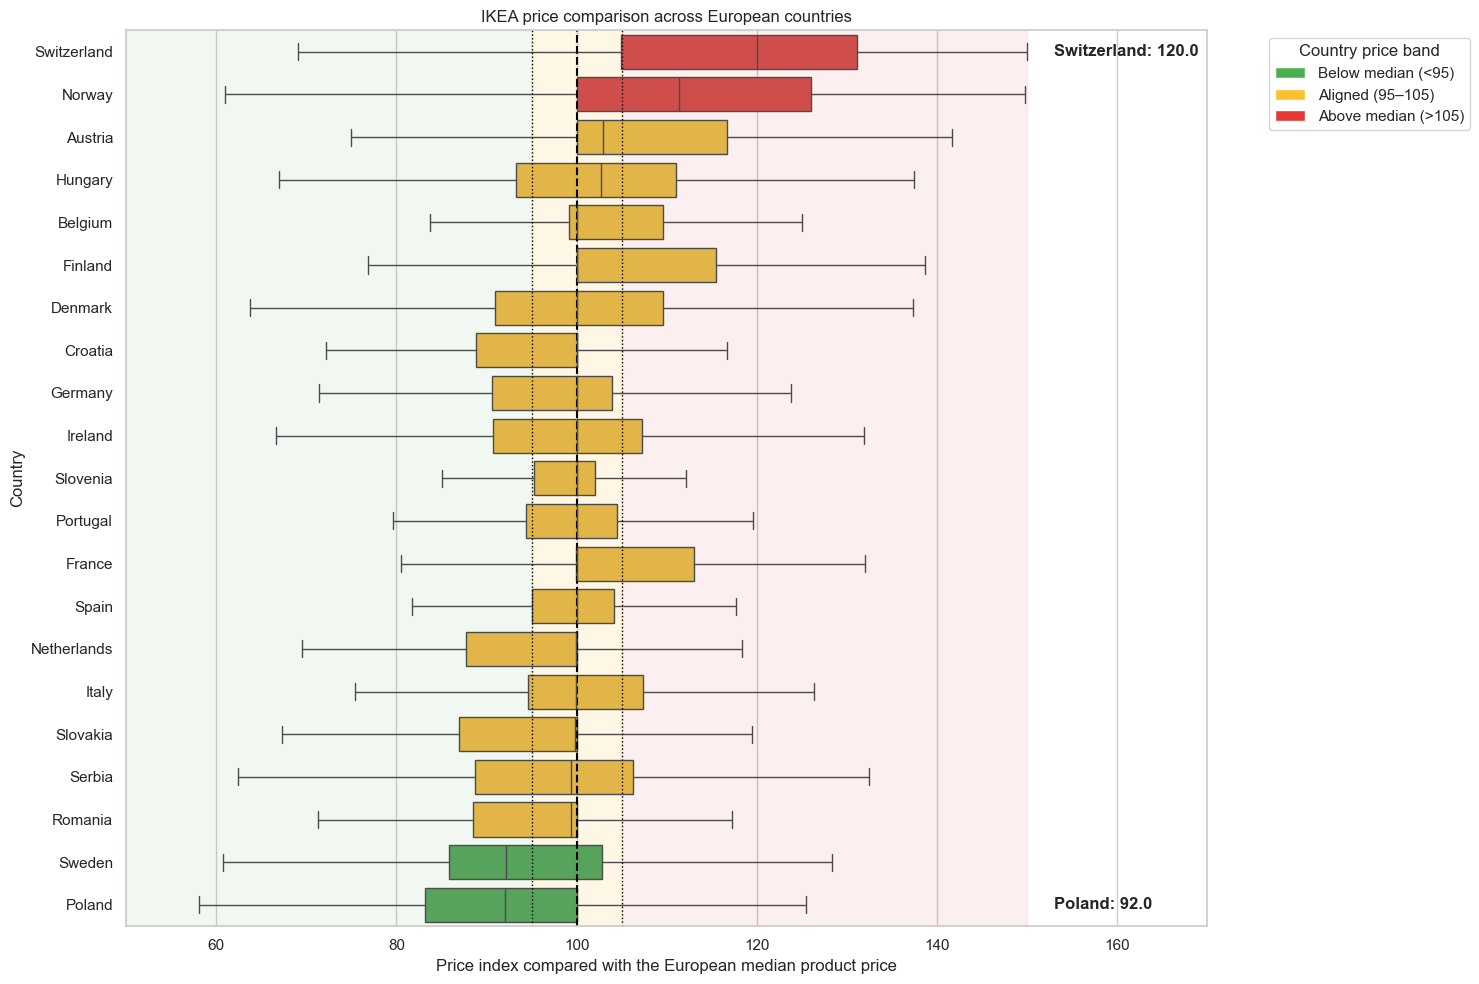

In [5]:
price_country = add_price_eur(df_europe).dropna(subset=['price_eur','country','product_id'])
valid = price_country.groupby('product_id')['country'].nunique().loc[lambda s: s == 21].index
price_country = price_country[price_country['product_id'].isin(valid)].copy()
price_country['price_index'] = price_country['price_eur'] / price_country.groupby('product_id')['price_eur'].transform('median') * 100
plot_df = price_country[(price_country['price_index'] >= 50) & (price_country['price_index'] <= 150)]
med = plot_df.groupby('country')['price_index'].median().sort_values(ascending=False)

#Colori per Grafico
band_colors = {'Below median':'#4CAF50','Aligned':'#FBC02D','Above median':'#E53935'} #dizionario
palette = {c: band_colors[country_price_band(med[c])] for c in med.index}

#Grafico
fig, ax = plt.subplots(figsize=(15, 10))

for start, end, color, alpha in [(50,95,'#4CAF50',.08), (95,105,'#FBC02D',.12), (105,150,'#E53935',.08)]: 
    ax.axvspan(start, end, alpha=alpha, color=color)
    
sns.boxplot(data=plot_df, x='price_index', y='country', order=med.index, hue='country', palette=palette, legend=False, showfliers=False, ax=ax)

for x, style, lw in [(95,':',1), (100,'--',1.5), (105,':',1)]: ax.axvline(x, linestyle=style, color='black', linewidth=lw)
    
for c in [med.idxmax(), med.idxmin()]: ax.text(153, list(med.index).index(c), f'{c}: {med[c]:.1f}', va='center', ha='left', fontsize=12, fontweight='bold')
    
ax.set(title='IKEA price comparison across European countries', xlabel='Price index compared with the European median product price', ylabel='Country', xlim=(50,170))

ax.legend(handles=[Patch(facecolor=v, label=f'{k} ({"<95" if k.startswith("Below") else "95–105" if k=="Aligned" else ">105"})') for k,v in band_colors.items()], title='Country price band', bbox_to_anchor=(1.05,1), loc='upper left')

style_axes([ax]); plt.tight_layout(); plt.show()


## Analysis 2 — How much of the IKEA catalog is not sellable online across countries?

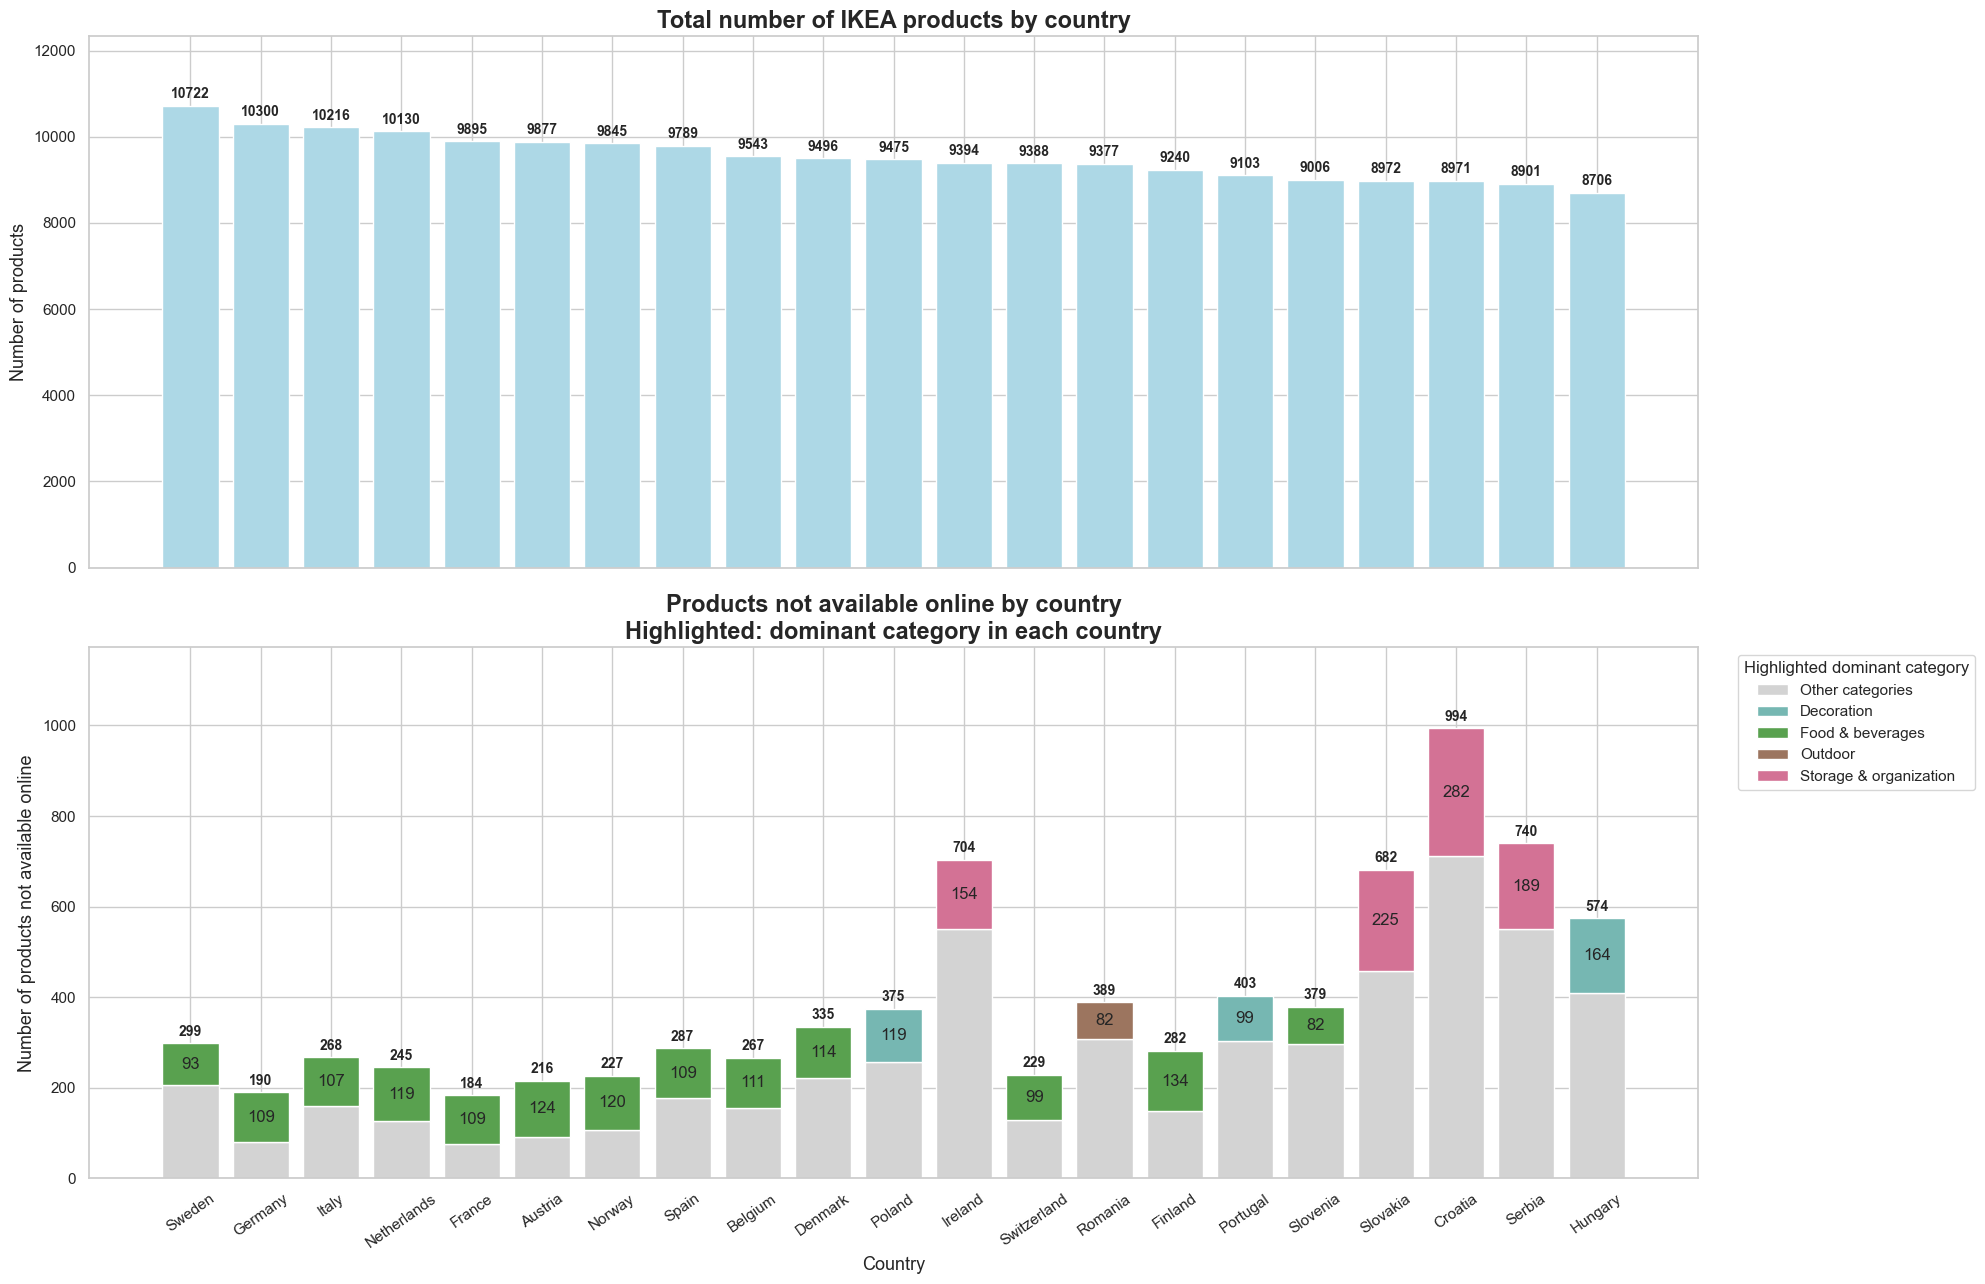

In [6]:
online_df = df_europe.assign(online_sellable=as_bool(df_europe['online_sellable']))
not_online = online_df[online_df['online_sellable'].eq(False)].dropna(subset=['country','main_category'])

cc = not_online.groupby(['country','main_category_group'], as_index=False).agg(not_online_products=('product_id','count'))
dominant = (cc.sort_values(['country','not_online_products'], ascending=[True,False]).groupby('country', as_index=False).first().rename(columns={'main_category_group':'dominant_category','not_online_products':'dominant_count'}))
summary = (online_df.groupby('country', as_index=False).agg(total_products=('product_id','count'))
           .merge(cc.groupby('country', as_index=False).agg(total_not_online=('not_online_products','sum')), how='left')
           .merge(dominant, how='left').fillna({'total_not_online':0,'dominant_count':0})
           .assign(other_count=lambda d: d.total_not_online - d.dominant_count)
           .sort_values('total_products', ascending=False).reset_index(drop=True))


#-------------------------PLOT----------------------------------
fig, axes = plt.subplots(2, 1, figsize=(20, 13), sharex=True)

#Impostazioni barre verticali axes[0] = Grafico 1, axes[1] = Grafico 2
axes[0].bar(summary.country, summary.total_products, color='lightblue')
axes[1].bar(summary.country, summary.other_count, color='lightgray', label='Other categories')
axes[1].bar(summary.country, summary.dominant_count, bottom=summary.other_count, color=summary.dominant_category.map(CATEGORY_COLORS).fillna('#999999'))

plots = [(axes[0], 'total_products', 'Total number of IKEA products by country', 'Number of products', 1.15),
         (axes[1], 'total_not_online', 'Products not available online by country\nHighlighted: dominant category in each country', 'Number of products not available online', 1.18)]


for ax, col, title, ylabel, mult in plots:
    ax.set_title(title, fontsize=17, fontweight='bold'); ax.set_ylabel(ylabel, fontsize=13); ax.set_ylim(0, summary[col].max() * mult)
    for i, v in enumerate(summary[col]): ax.text(i, v + summary[col].max()*.01, f'{int(v)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for i, r in summary.iterrows():
    if r.dominant_count >= 25: axes[1].text(i, r.other_count + r.dominant_count/2, f'{int(r.dominant_count)}', ha='center', va='center', fontsize=12)
axes[1].set_xlabel('Country', fontsize=13); axes[1].tick_params(axis='x', rotation=35)
handles = [Patch(facecolor='lightgray', label='Other categories')] + [Patch(facecolor=CATEGORY_COLORS.get(c, '#999999'), label=c) for c in sorted(summary.dominant_category.dropna().unique())]
axes[1].legend(handles=handles, title='Highlighted dominant category', bbox_to_anchor=(1.02,1), loc='upper left')
style_axes(axes); plt.tight_layout(); plt.show()


## Analysis 3 — Which IKEA categories are most present across European countries?

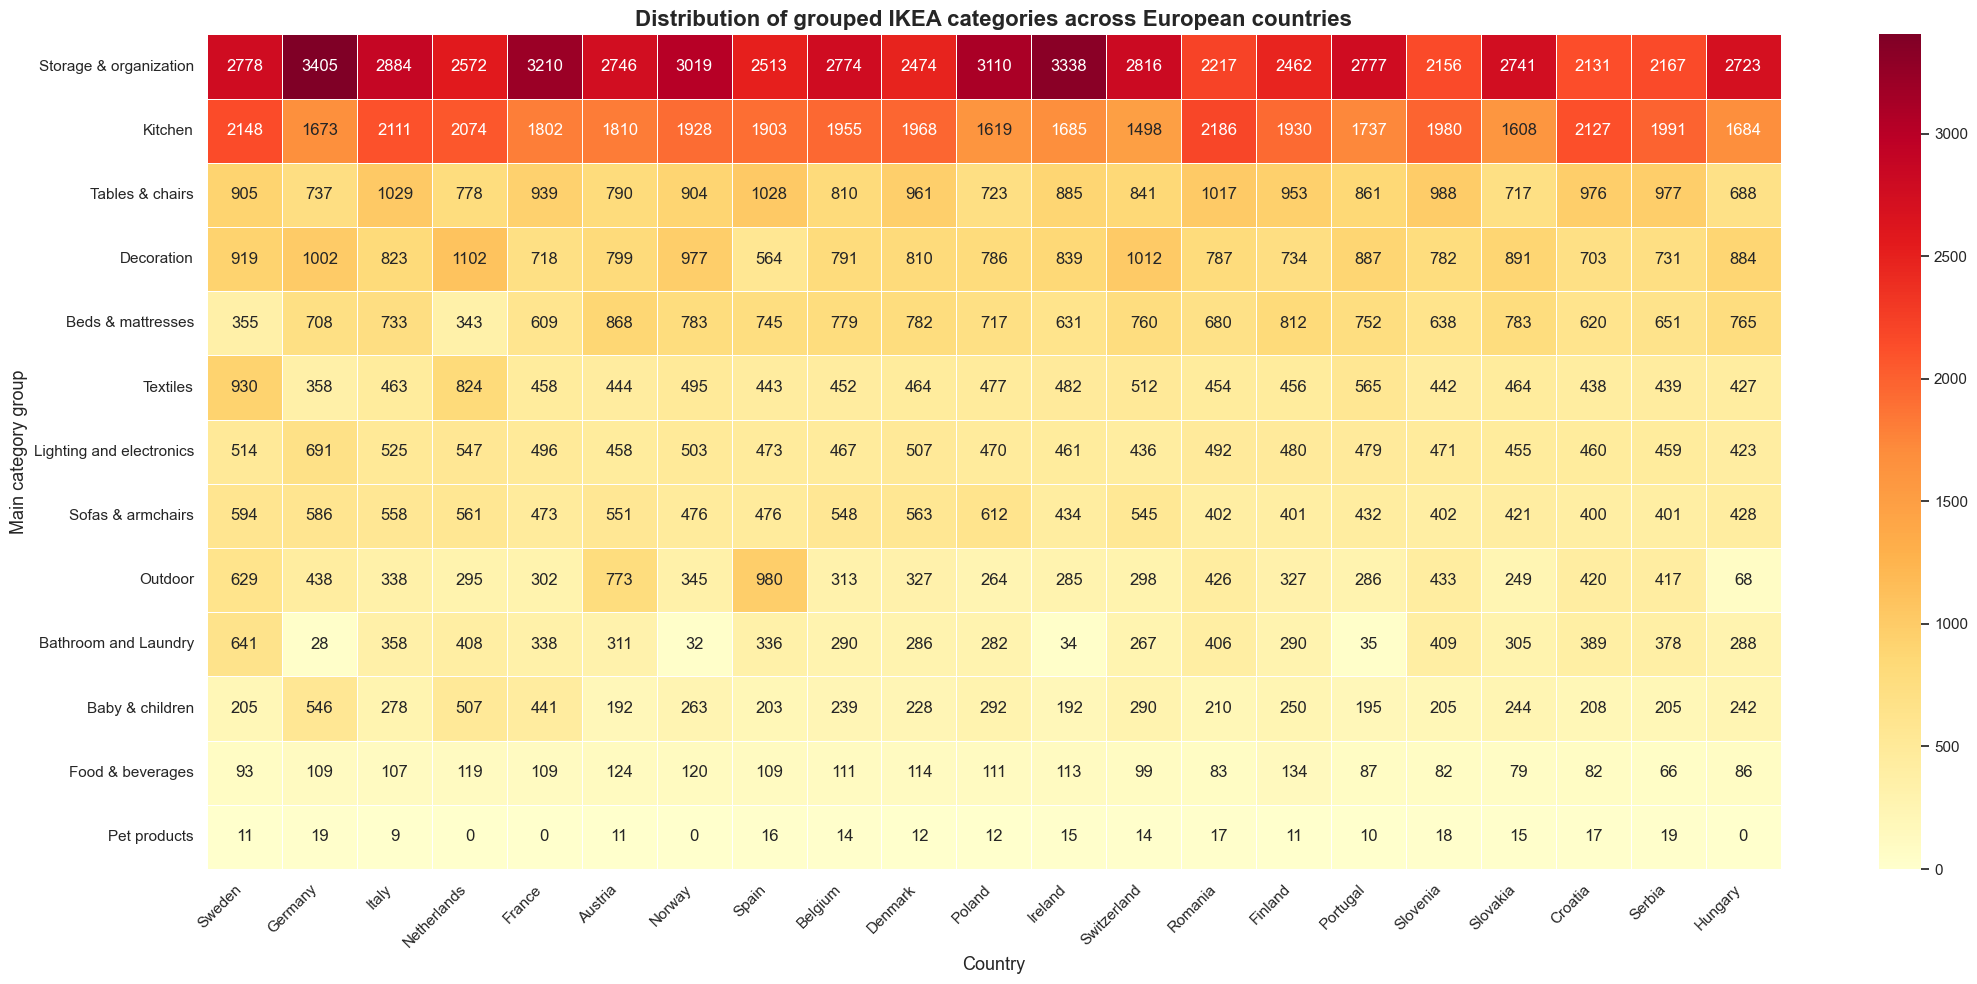

In [7]:
cat_country = df_europe.dropna(subset=['country','main_category_group','product_id'])
pivot = sorted_pivot(cat_country, 'main_category_group', 'country', 'product_id', 'count', 0)
pivot = pivot.reindex(columns=sorted(df_europe['country'].dropna().unique()), fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index, pivot.sum(axis=0).sort_values(ascending=False).index]

plt.figure(figsize=(22, 10))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=.5, linecolor='white', annot=True, fmt='d')
plt.title('Distribution of grouped IKEA categories across European countries', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=13); plt.ylabel('Main category group', fontsize=13)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()


## Analysis 4 — Are TOP_SELLER products rated better than other products?

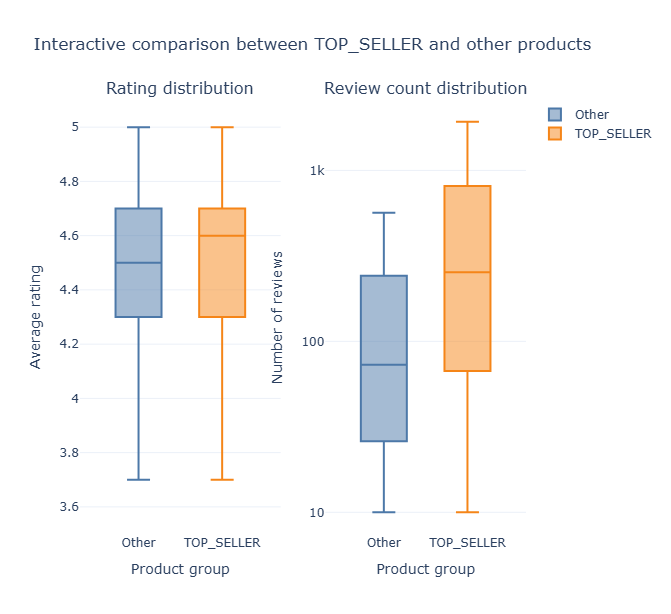

In [8]:
top_seller = rated_products(df_europe.copy(), 10).assign(badge_group=lambda d: np.where(d['badge'].eq('TOP_SELLER'), 'TOP_SELLER', 'Other'))
groups, colors, positions = ['Other','TOP_SELLER'], {'Other':'#4C78A8','TOP_SELLER':'#F58518'}, {'Other':0,'TOP_SELLER':1}
fig = make_subplots(rows=1, cols=2, subplot_titles=['Rating distribution', 'Review count distribution'])
add_manual_box(fig, box_stats(top_seller, 'badge_group', 'product_rating', groups), 1, colors, positions, 2)
add_manual_box(fig, box_stats(top_seller, 'badge_group', 'product_rating_count', groups), 2, colors, positions, 0, False)
for c in [1, 2]: fig.update_xaxes(title_text='Product group', tickmode='array', tickvals=[0,1], ticktext=groups, range=[-.7,1.7], row=1, col=c)
fig.update_yaxes(title_text='Average rating', range=[3.5,5.1], row=1, col=1)
fig.update_yaxes(title_text='Number of reviews', type='log', tickmode='array', tickvals=[10,100,1000,10000], ticktext=['10','100','1k','10k'], minor=dict(ticks='', showgrid=False), row=1, col=2)
fig.update_layout(title='Interactive comparison between TOP_SELLER and other products', width=1200, height=600, template='plotly_white', boxmode='overlay')
fig.show()


## Analysis 5 — How does the rating of the same product change across European countries?

Selected product: BILLY
Product ID: 263850
Number of countries: 20


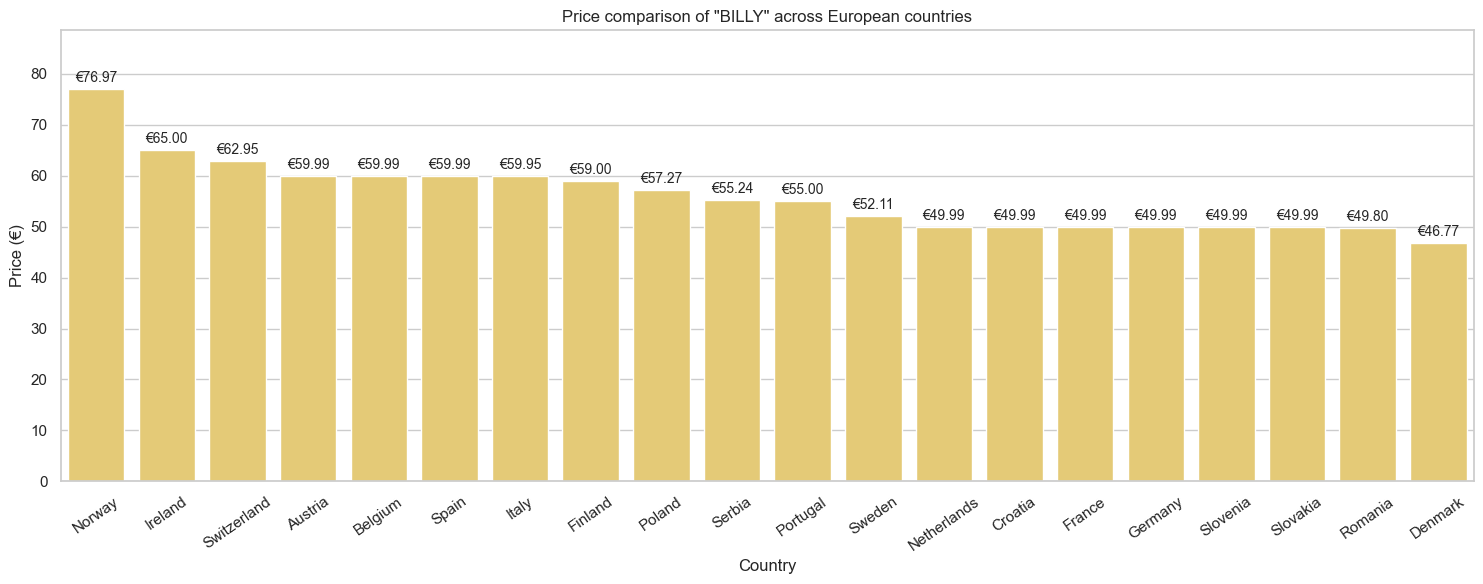

In [36]:
billy_product = (
    add_price_eur(df_europe.copy())
    .dropna(subset=['product_id', 'product_name', 'country', 'price_eur'])
    .assign(price_eur=lambda d: pd.to_numeric(d['price_eur'], errors='coerce'))
    .dropna(subset=['price_eur'])
)

selected_id = 263850

billy_product = (
    billy_product[billy_product['product_id'].eq(selected_id)]
    .groupby(['product_id', 'product_name', 'country'], as_index=False)
    .agg(price_eur=('price_eur', 'median'))
    .sort_values('price_eur', ascending=False)
)

selected_name = billy_product['product_name'].iloc[0]

print('Selected product:', selected_name)
print('Product ID:', selected_id)
print('Number of countries:', billy_product['country'].nunique())

fig, ax = plt.subplots(figsize=(15, 6))

sns.barplot(
    data=billy_product,
    x='country',
    y='price_eur',
    ax=ax,
    color='#F6D365'
)

ax.set(
    title=f'Price comparison of "{selected_name}" across European countries',
    xlabel='Country',
    ylabel='Price (€)'
)

add_bar_labels(ax, billy_product['price_eur'], fmt='€{:.2f}')

ax.set_ylim(0, billy_product['price_eur'].max() * 1.15)
ax.tick_params(axis='x', rotation=35)

style_axes([ax])
plt.tight_layout()
plt.show()

## Analysis 6 — Are IKEA promotional tags associated with different prices or ratings?

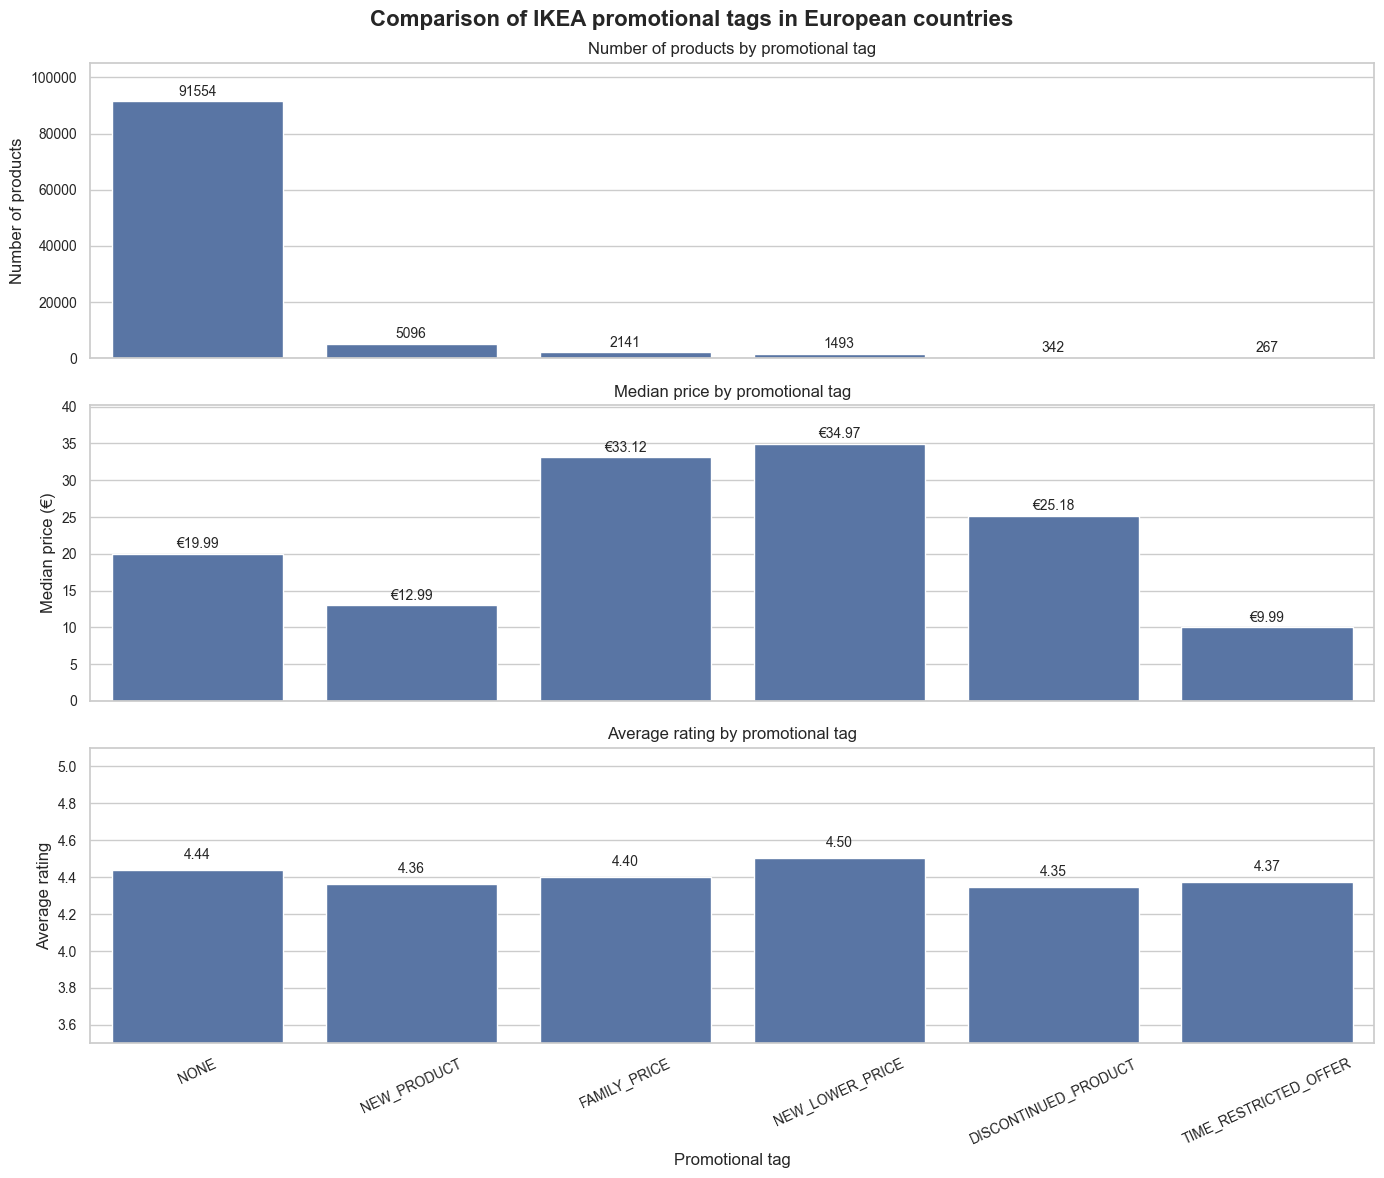

In [10]:
sale = rated_products(add_price_eur(df_europe.copy()), 10, ['sale_tag','price_eur'])
sale['sale_tag'] = sale['sale_tag'].astype(str).str.strip()
sale = sale[sale['sale_tag'].ne('') & sale['sale_tag'].str.lower().ne('nan')]
sale = sale[sale['sale_tag'].isin(top_values(sale, 'sale_tag', 6))]
sum_sale = (sale.groupby('sale_tag').agg(product_count=('product_id','count'), median_price_eur=('price_eur','median'), mean_rating=('product_rating','mean')).sort_values('product_count', ascending=False).reset_index())

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for ax, col, title, ylabel, fmt in zip(axes, ['product_count','median_price_eur','mean_rating'], ['Number of products by promotional tag','Median price by promotional tag','Average rating by promotional tag'], ['Number of products','Median price (€)','Average rating'], ['{:.0f}','€{:.2f}','{:.2f}']):
    sns.barplot(data=sum_sale, x='sale_tag', y=col, ax=ax); ax.set(title=title, xlabel='', ylabel=ylabel); add_bar_labels(ax, sum_sale[col], fmt=fmt)
    if col != 'mean_rating': ax.set_ylim(0, sum_sale[col].max() * 1.15)
axes[2].set(xlabel='Promotional tag', ylim=(3.5,5.1)); axes[2].tick_params(axis='x', rotation=25)
style_axes(axes, 10); plt.suptitle('Comparison of IKEA promotional tags in European countries', fontsize=16, fontweight='bold'); plt.tight_layout(); plt.show()


## Analysis 7 — Are some IKEA categories rated better in certain countries?

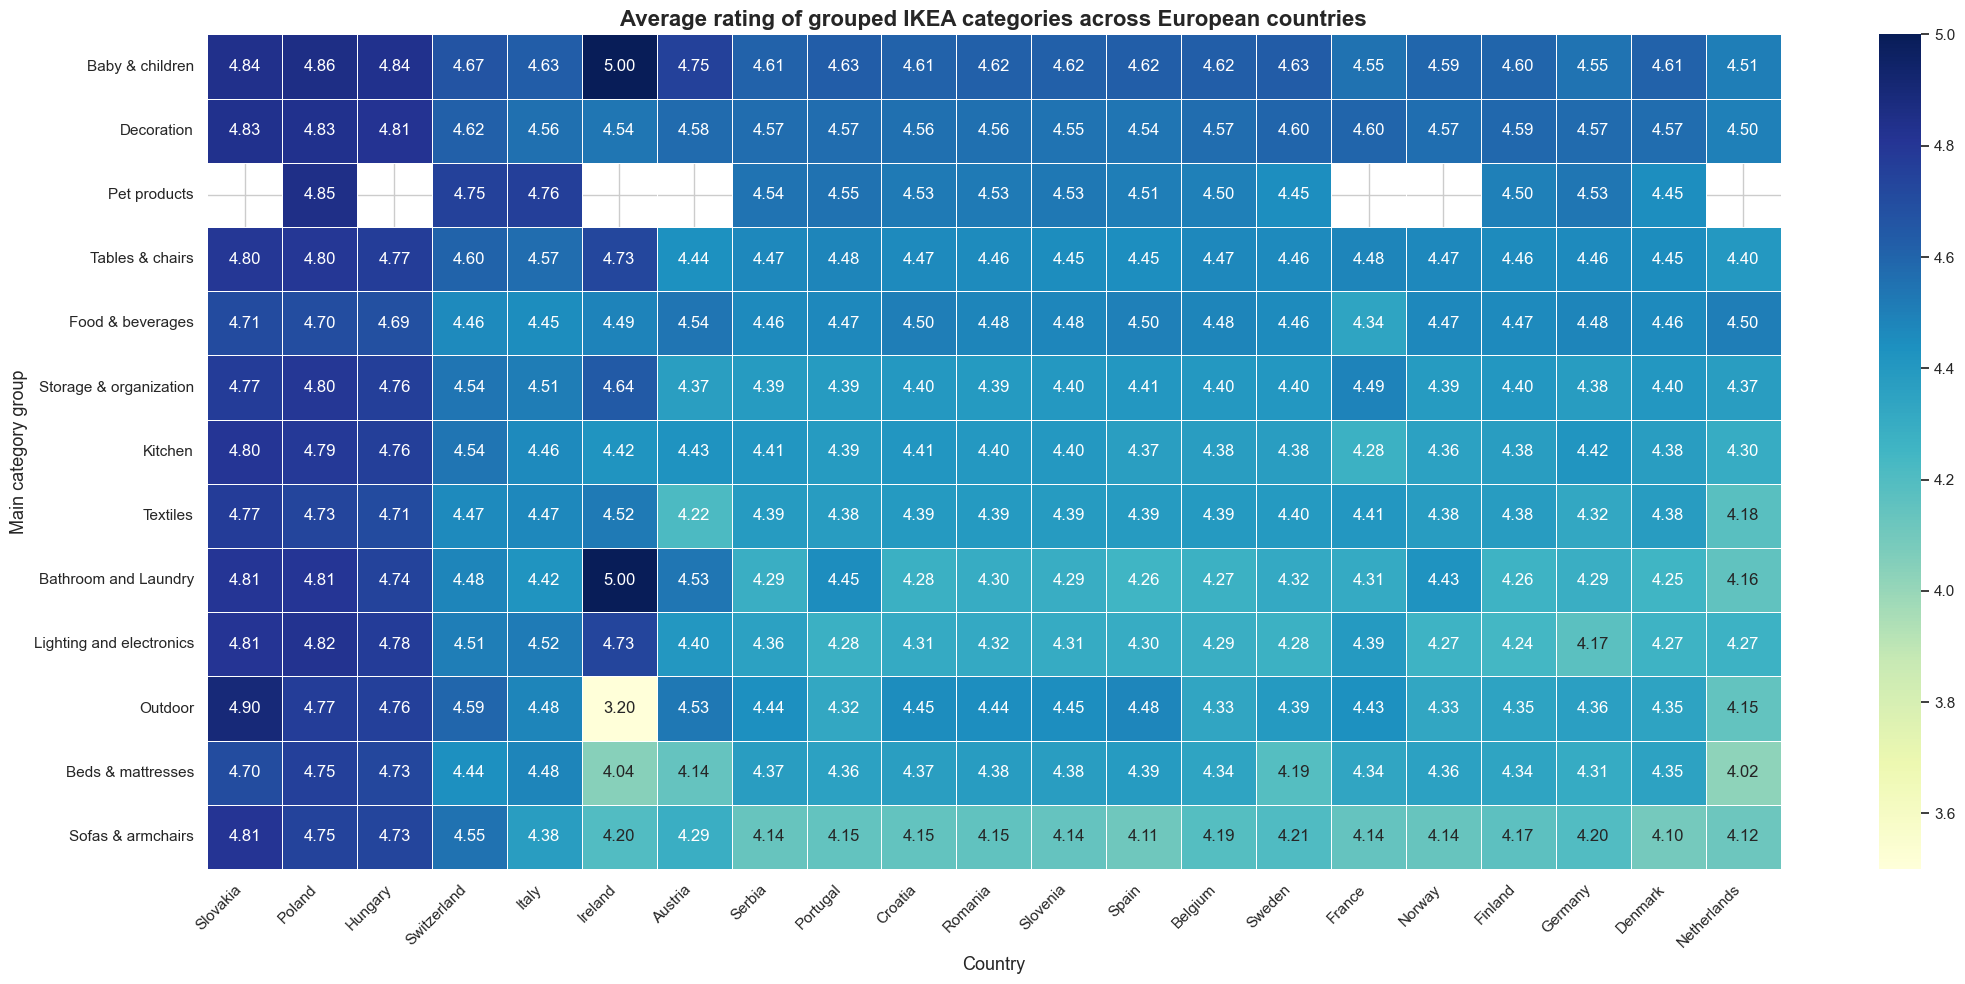

In [11]:
rating_heatmap = rated_products(df_europe.copy(), 10, ['country','main_category_group'])
pivot = rating_heatmap.pivot_table(index='main_category_group', columns='country', values='product_rating', aggfunc='mean')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index, pivot.mean(axis=0).sort_values(ascending=False).index]
plt.figure(figsize=(22, 10))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=.5, linecolor='white', vmin=3.5, vmax=5)
plt.title('Average rating of grouped IKEA categories across European countries', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=13); plt.ylabel('Main category group', fontsize=13)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()


## Analysis 8 — Do more expensive products have better ratings?

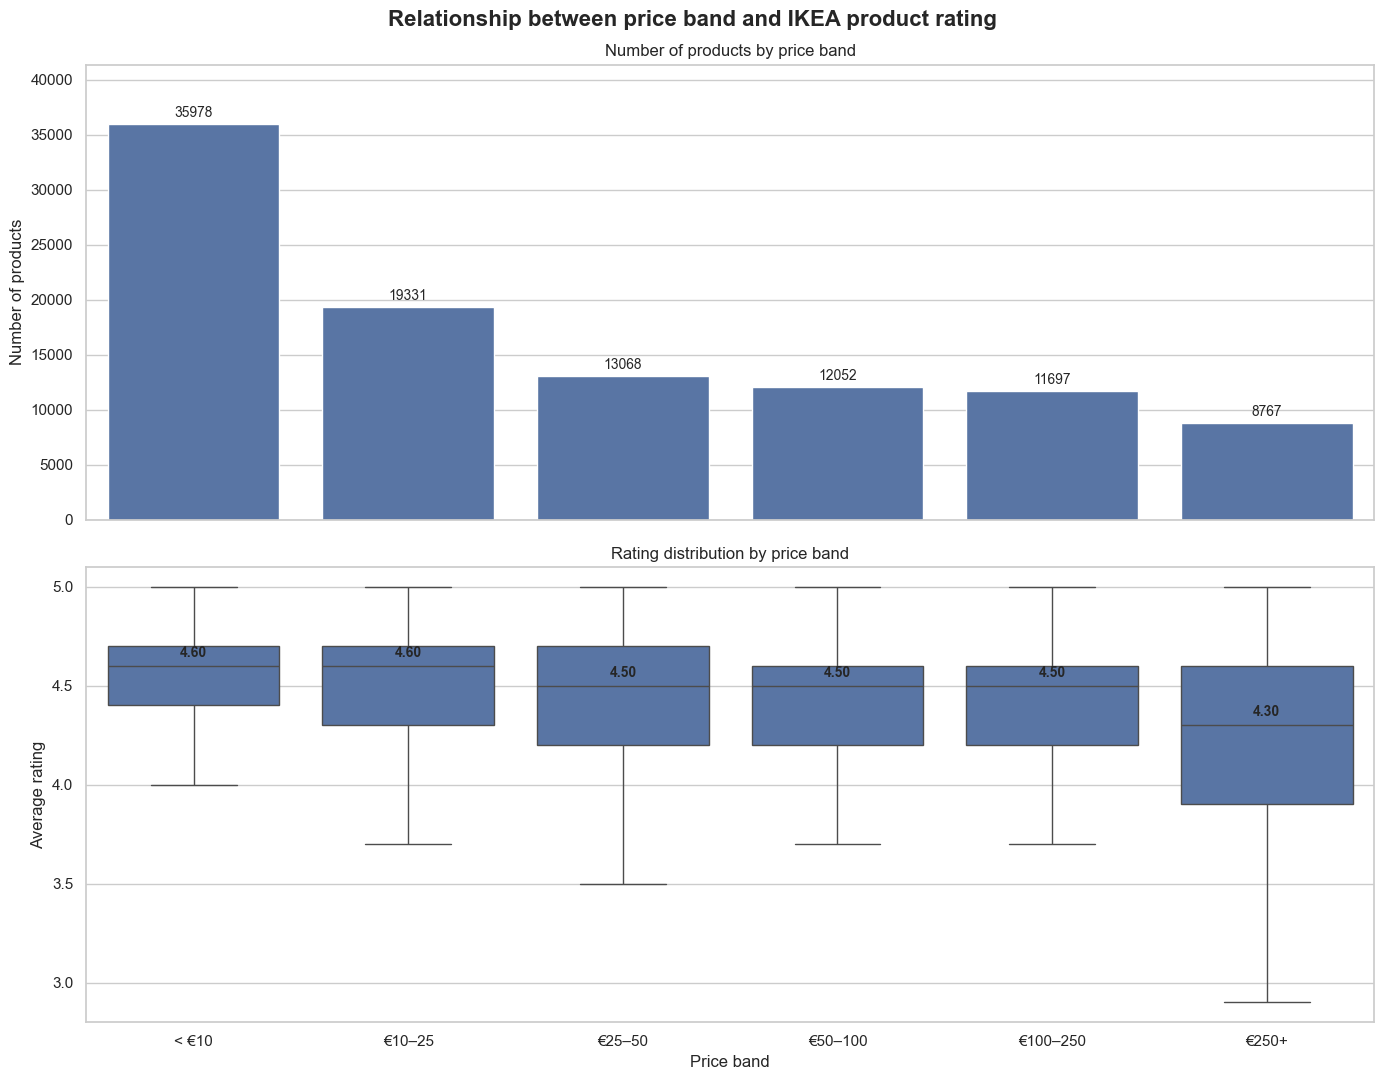

In [12]:
price_rating = rated_products(add_price_eur(df_europe.copy()), 10, ['price_eur'])
price_rating['price_band'] = pd.cut(price_rating['price_eur'], PRICE_BINS, labels=PRICE_LABELS, include_lowest=True)
price_rating = price_rating.dropna(subset=['price_band'])
price_summary = price_rating.groupby('price_band', observed=False).agg(product_count=('product_id','count'), median_rating=('product_rating','median'), mean_rating=('product_rating','mean')).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
sns.barplot(data=price_summary, x='price_band', y='product_count', order=PRICE_LABELS, ax=axes[0])
sns.boxplot(data=price_rating, x='price_band', y='product_rating', order=PRICE_LABELS, showfliers=False, ax=axes[1])
axes[0].set(title='Number of products by price band', xlabel='', ylabel='Number of products'); axes[0].set_ylim(0, price_summary.product_count.max() * 1.15)
axes[1].set(title='Rating distribution by price band', xlabel='Price band', ylabel='Average rating', ylim=(2.8,5.1))
add_bar_labels(axes[0], price_summary['product_count'])
for i, r in price_summary.iterrows(): axes[1].text(i, r.median_rating + .03, f'{r.median_rating:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
style_axes(axes); plt.suptitle('Relationship between price band and IKEA product rating', fontsize=16, fontweight='bold'); plt.tight_layout(); plt.show()


## Analysis 9 — Does product rating change by country compared with the European average?

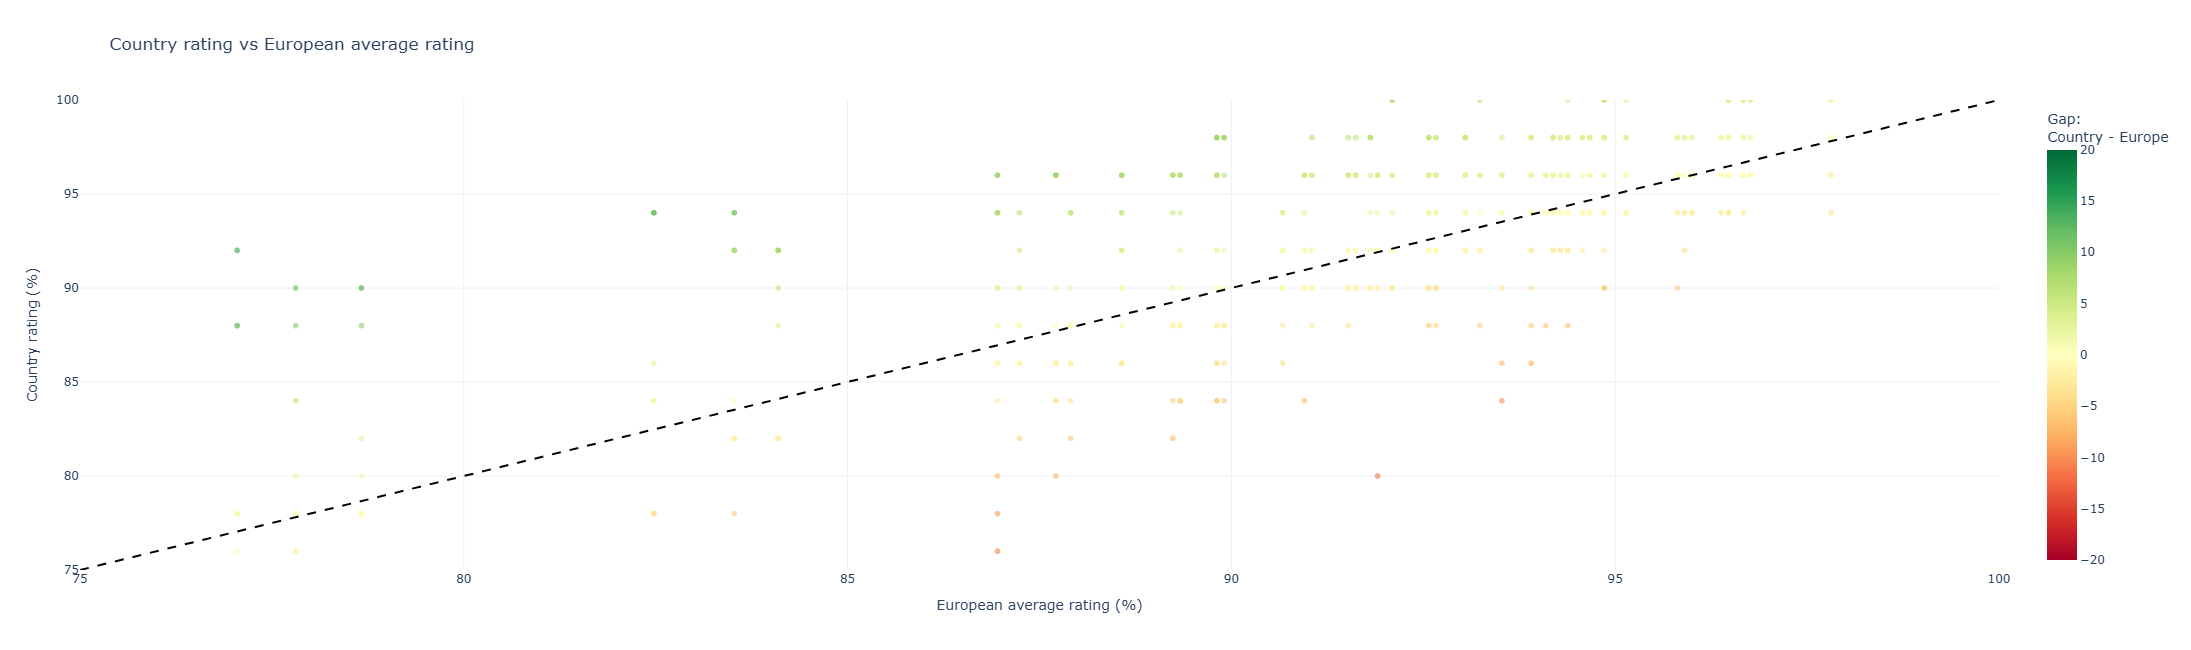

In [37]:
country_vs_europe = rated_products(df_europe.copy(), 10, ['product_id','product_name','country'])
valid = country_vs_europe.groupby('product_id')['country'].nunique().loc[lambda s: s == 21].index
country_vs_europe = country_vs_europe[country_vs_europe['product_id'].isin(valid)].copy()
country_vs_europe['europe_rating'] = country_vs_europe.groupby('product_id')['product_rating'].transform('mean')
country_vs_europe = country_vs_europe.assign(country_rating_pct=lambda d: d.product_rating*20, europe_rating_pct=lambda d: d.europe_rating*20, rating_gap=lambda d: d.country_rating_pct-d.europe_rating_pct)
plot_df = country_vs_europe.sample(n=4000, random_state=42) if len(country_vs_europe) > 4000 else country_vs_europe.copy()
bounds = pd.concat([plot_df.europe_rating_pct, plot_df.country_rating_pct]).quantile([.01,.99])
lower, upper = int(max(0, bounds.iloc[0]-2)//5*5), int((min(100, bounds.iloc[1]+2)+4)//5*5)
plot_df = plot_df.query('@lower <= europe_rating_pct <= @upper and @lower <= country_rating_pct <= @upper')

fig = px.scatter(plot_df, x='europe_rating_pct', y='country_rating_pct', color='rating_gap', color_continuous_scale='RdYlGn', 
                 range_color=[-20,20], hover_data={'product_name':True,'country':True,'product_rating_count':True,'europe_rating_pct':':.1f','country_rating_pct':':.1f','rating_gap':':.1f'}, 
                 labels={'europe_rating_pct':'European average rating (%)','country_rating_pct':'Country rating (%)','rating_gap':'Gap','product_name':'Product','country':'Country','product_rating_count':'Number of reviews'}, 
                 title='Country rating vs European average rating')
fig.update_traces(marker=dict(size=6, opacity=.6), selector=dict(mode='markers'))
fig.add_shape(type='line', x0=lower, y0=lower, x1=upper, y1=upper, line=dict(color='black', dash='dash'))
fig.update_xaxes(title='European average rating (%)', range=[lower, upper]); fig.update_yaxes(title='Country rating (%)', range=[lower, upper])
fig.update_layout(width=1050, height=650, template='plotly_white', coloraxis_colorbar=dict(title='Gap:<br>Country - Europe'))
fig.show()
